In [2]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import torch.nn as nn

In [3]:
def build_grid(target, neighbors, grid_size=4, cell_size=1.0):
    grid = np.zeros((grid_size, grid_size))

    center = grid_size // 2

    for nx, ny in neighbors:
        dx = nx - target[0]
        dy = ny - target[1]

        gx = int(dx / cell_size) + center
        gy = int(dy / cell_size) + center

        if 0 <= gx < grid_size and 0 <= gy < grid_size:
            grid[gx, gy] = 1

    return grid.flatten()

In [4]:
class SocialLSTM(nn.Module):
    def __init__(self,
                 pos_dim    = 2,
                 social_dim = 16,   # 16
                 embed_dim  = 64,
                 hidden_dim = 64,
                 pred_len   = 6):
        super().__init__()
        self.pred_len = pred_len

        # FIX: declare the layers that forward() uses
        self.pos_fc    = nn.Linear(pos_dim,    embed_dim)
        self.social_fc = nn.Linear(social_dim, embed_dim)
        self.lstm      = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc        = nn.Linear(hidden_dim, pos_dim)

    def forward(self, x, social):
        B, T, _ = x.shape

        embeddings = []
        for t in range(T):
            pos = x[:, t, :]        # (B, 2)
            soc = social[:, t, :]   # (B, 16)

            pos_emb = torch.relu(self.pos_fc(pos))      # (B, 64)
            soc_emb = torch.relu(self.social_fc(soc))   # (B, 64)

            combined = pos_emb + soc_emb                # (B, 64)
            embeddings.append(combined)

        embeddings = torch.stack(embeddings, dim=1)     # (B, T, 64)

        _, (h, c) = self.lstm(embeddings)               # h: (1, B, hidden)


        dec_input = x[:, -1:, :]   # (B, 1, 2) — last observed step
        outputs   = []
        for _ in range(self.pred_len):
            pos_emb  = torch.relu(self.pos_fc(dec_input.squeeze(1)))
            soc_zero = torch.zeros(B, 16, device=x.device)  # no future social
            soc_emb  = torch.relu(self.social_fc(soc_zero))
            combined = (pos_emb + soc_emb).unsqueeze(1)             # (B,1,64)
            out, (h, c) = self.lstm(combined, (h, c))
            step = self.fc(out)          # (B, 1, 2)
            outputs.append(step)
            dec_input = step             # teacher-forcing off at inference

        return torch.cat(outputs, dim=1)     # (B, pred_len, 2)

In [5]:
import json
from collections import defaultdict

def load_data(data_dir="."):
    with open("sample_annotation.json") as f:
        annotations = json.load(f)
    with open("instance.json") as f:
        instances = json.load(f)
    with open("category.json") as f:
        categories = json.load(f)
    with open("sample.json") as f:
        samples = json.load(f)

    cat_map = {c["token"]: c["name"] for c in categories}
    sample_order = {s["token"]: s["timestamp"] for s in samples}

    ped_tokens = {
        i["token"]
        for i in instances
        if "human.pedestrian" in cat_map.get(i["category_token"], "")
    }

    trajectories = defaultdict(list)
    for ann in annotations:
        if ann["instance_token"] in ped_tokens:
            trajectories[ann["instance_token"]].append((
                ann["sample_token"],
                ann["translation"][0],
                ann["translation"][1],
            ))

    frame_map = defaultdict(list)
    for ann in annotations:
        if ann["instance_token"] in ped_tokens:
            frame_map[ann["sample_token"]].append((
                ann["instance_token"],
                ann["translation"][0],
                ann["translation"][1],
            ))

    for pid in trajectories:                                # now sample_order exists
        trajectories[pid].sort(key=lambda x: sample_order.get(x[0], 0))

    return trajectories, frame_map

In [6]:
def add_noise(window, sigma=0.05):
    """small Gaussian noise to all positions (~5cm noise)"""
    noise = np.random.normal(0, sigma, window.shape)
    return window + noise


def augment_rotate(window):
    """Rotate entire trajectory by a random angle 0-360°"""
    angle = np.random.uniform(0, 2 * np.pi)
    cos_a = np.cos(angle)
    sin_a = np.sin(angle)
    x_new =  window[:, 0] * cos_a + window[:, 1] * sin_a
    y_new = -window[:, 0] * sin_a + window[:, 1] * cos_a
    return np.stack([x_new, y_new], axis=-1)


In [7]:
def build_windows(trajectories, frame_map):
    obs_windows    = []
    target_windows = []
    social_windows = []
    OBS_LEN     = 4
    PRED_LEN    = 6
    WINDOW_SIZE = OBS_LEN + PRED_LEN

    for ped_id, path in trajectories.items():
        if len(path) < WINDOW_SIZE:
            continue

        sample_tokens = [p[0] for p in path]
        coords        = np.array([[p[1], p[2]] for p in path])

        for i in range(len(coords) - WINDOW_SIZE + 1):
            window       = coords[i : i + WINDOW_SIZE].copy()
            token_window = sample_tokens[i : i + WINDOW_SIZE]

            # filter tracking errors
            diffs = np.diff(window, axis=0)
            if np.any(np.linalg.norm(diffs, axis=1) > 3.0):
                continue

            # normalize
            origin = window[0].copy()
            window = window - origin

            # ── helper to process one window and append ──────────
            def process_and_append(w):
                disp     = np.zeros_like(w)
                disp[1:] = w[1:] - w[:-1]

                social_seq = []
                for t in range(OBS_LEN):
                    time_token = token_window[t]
                    target_pos = w[t]
                    neighbors  = [
                        (nx - origin[0], ny - origin[1])
                        for pid2, nx, ny in frame_map[time_token]
                        if pid2 != ped_id
                    ]
                    social_seq.append(build_grid(target_pos, neighbors, cell_size=2.0))

                obs_windows.append(disp[:OBS_LEN])
                target_windows.append(disp[OBS_LEN:])
                social_windows.append(np.array(social_seq))

            # original window
            process_and_append(window)

            # augmentation 1 — gaussian noise
            process_and_append(add_noise(window, sigma=0.05))

            # augmentation 2 — random rotation
            process_and_append(augment_rotate(window))

    return (np.array(obs_windows),
            np.array(target_windows),
            np.array(social_windows))

In [8]:
def ade(pred, gt):
    pred_pos = np.cumsum(pred, axis=0)
    gt_pos   = np.cumsum(gt,   axis=0)
    return np.sqrt(((pred_pos - gt_pos) ** 2).sum(-1)).mean()


def fde(pred, gt):
    pred_pos = np.cumsum(pred, axis=0)
    gt_pos   = np.cumsum(gt,   axis=0)
    return np.sqrt(((pred_pos[-1] - gt_pos[-1]) ** 2).sum())

In [9]:

def train(obs_np, target_np, social_np, epochs=100, lr=5e-4, batch=64):
    device = "cuda" if torch.cuda.is_available() else "cpu"

    obs_t    = torch.tensor(obs_np,    dtype=torch.float32).to(device)
    target_t = torch.tensor(target_np, dtype=torch.float32).to(device)
    social_t = torch.tensor(social_np, dtype=torch.float32).to(device)

    dataset = torch.utils.data.TensorDataset(obs_t, social_t, target_t)
    loader  = torch.utils.data.DataLoader(dataset, batch_size=batch, shuffle=True)

    model     = SocialLSTM().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        for obs_b, soc_b, tgt_b in loader:
            pred = model(obs_b, soc_b)      # (B, pred_len, 2)
            loss = criterion(pred, tgt_b)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        if (epoch + 1) % 1 == 0:
            print(f"Epoch {epoch + 1}/{epochs}, Loss: {total_loss / len(loader)}")



    return model

In [10]:
trajectories, frame_map = load_data(".")
obs_np, target_np, social_np = build_windows(trajectories, frame_map)
from sklearn.model_selection import train_test_split
(obs_train, obs_test,
     tgt_train, tgt_test,
     soc_train, soc_test) = train_test_split(
        obs_np, target_np, social_np,
        test_size=0.2,      # 80% train, 20% test
        random_state=42,
    )


EPOCHS = 100

    # ── Train ───────────────────────────────────────────────────
model = train(obs_train, tgt_train, soc_train, epochs=100)

    # ── Evaluate on test set ────────────────────────────────────
model.eval()
device = next(model.parameters()).device

with torch.no_grad():
    pred = model(
        torch.tensor(obs_test,dtype=torch.float32 ,device=device),

        torch.tensor(soc_test,dtype=torch.float32 ,device=device),
        ).cpu().numpy()

    ades = [ade(pred[i], tgt_test[i]) for i in range(len(pred))]
    fdes = [fde(pred[i], tgt_test[i]) for i in range(len(pred))]

    print(np.mean(ades))
    print(np.mean(fdes))



Epoch 1/100, Loss: 0.054398539073575856
Epoch 2/100, Loss: 0.015488648124165455
Epoch 3/100, Loss: 0.01455084536761298
Epoch 4/100, Loss: 0.014233143124097989
Epoch 5/100, Loss: 0.013854520111265829
Epoch 6/100, Loss: 0.013868527171217788
Epoch 7/100, Loss: 0.013753645169406624
Epoch 8/100, Loss: 0.013537818005592641
Epoch 9/100, Loss: 0.013612430945228217
Epoch 10/100, Loss: 0.013416637058796014
Epoch 11/100, Loss: 0.013318965179940401
Epoch 12/100, Loss: 0.013167501174671165
Epoch 13/100, Loss: 0.013151238542207974
Epoch 14/100, Loss: 0.01318753880874838
Epoch 15/100, Loss: 0.013206659595213704
Epoch 16/100, Loss: 0.01306291535038943
Epoch 17/100, Loss: 0.012875051663841232
Epoch 18/100, Loss: 0.012935158733467934
Epoch 19/100, Loss: 0.012808580906525
Epoch 20/100, Loss: 0.012859689095452174
Epoch 21/100, Loss: 0.012731122141072557
Epoch 22/100, Loss: 0.012694443505004807
Epoch 23/100, Loss: 0.012481925748604334
Epoch 24/100, Loss: 0.012534591377223446
Epoch 25/100, Loss: 0.012374972

In [13]:
def get_best_moving_predictions(model, obs_test, soc_test, tgt_test, min_dist=3.0, k=5):
    model.eval()
    device = next(model.parameters()).device
    results = []

    with torch.no_grad():
        # Move test data to GPU
        obs_t = torch.tensor(obs_test, dtype=torch.float32, device=device)
        soc_t = torch.tensor(soc_test, dtype=torch.float32, device=device)
        preds = model(obs_t, soc_t).cpu().numpy()

    for i in range(len(preds)):
        # 1. Calculate how far they actually moved (Total Distance)
        # We sum the ground truth displacements to get the final position
        actual_path = np.cumsum(tgt_test[i], axis=0)
        total_moved = np.linalg.norm(actual_path[-1])

        # 2. Only keep them if they moved more than our threshold (min_dist)
        if total_moved >= min_dist:
            # Calculate FDE (How far off was the final prediction?)
            pred_path = np.cumsum(preds[i], axis=0)
            fde_score = np.linalg.norm(pred_path[-1] - actual_path[-1])

            results.append({
                'index': i,
                'fde': fde_score,
                'dist': total_moved,
                'pred': pred_path,
                'gt': actual_path
            })

    # 3. Sort by FDE (lowest error first) and take top K
    results.sort(key=lambda x: x['fde'])
    return results[:k]

# Run the search for people moving at least 3 meters
top_moving = get_best_moving_predictions(model, obs_test, soc_test, tgt_test, min_dist=3.0)

print(f"--- Top {len(top_moving)} Moving Predictions (>3m) ---")
for i, res in enumerate(top_moving):
    print(f"Rank {i+1}: Index {res['index']} | Moved: {res['dist']:.2f}m | Error: {res['fde']:.4f}m")

--- Top 5 Moving Predictions (>3m) ---
Rank 1: Index 446 | Moved: 3.80m | Error: 0.0152m
Rank 2: Index 1278 | Moved: 3.64m | Error: 0.0167m
Rank 3: Index 1651 | Moved: 3.38m | Error: 0.0239m
Rank 4: Index 363 | Moved: 3.40m | Error: 0.0250m
Rank 5: Index 564 | Moved: 3.42m | Error: 0.0301m


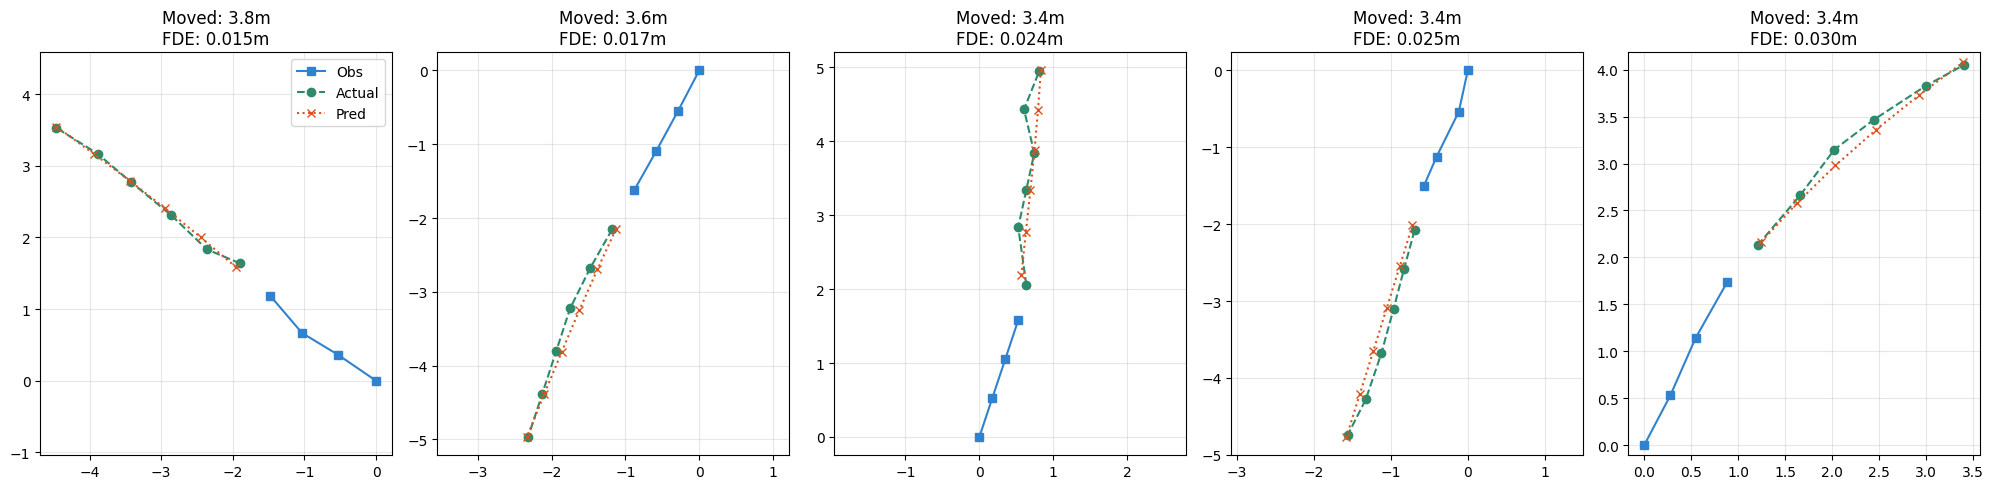

In [16]:
plt.figure(figsize=(20, 5))

for i, res in enumerate(top_moving):
    plt.subplot(1, 5, i+1)

    idx = res['index']
    # Get past positions for context
    past_pos = np.cumsum(obs_test[idx], axis=0)
    # The actual and predicted paths start where the past ended
    actual_f = past_pos[-1] + res['gt']
    pred_f = past_pos[-1] + res['pred']

    # --- Plotting ---
    plt.plot(past_pos[:, 0], past_pos[:, 1], color='#3182ce', marker='s', label='Obs')
    plt.plot(actual_f[:, 0], actual_f[:, 1], color='#2d8a6a', marker='o', linestyle='--', label='Actual')
    plt.plot(pred_f[:, 0], pred_f[:, 1], color='#d9531e', marker='x', linestyle=':', label='Pred')

    plt.title(f"Moved: {res['dist']:.1f}m\nFDE: {res['fde']:.3f}m")
    plt.axis('equal')
    plt.grid(True, alpha=0.3)
    if i == 0: plt.legend()

plt.tight_layout()
plt.show()